In [1]:
#Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)

In [2]:
#Cell 2 — Load all 4 tables
labels      = pd.read_csv('Train-1542865627584.csv')
beneficiary = pd.read_csv('Train_Beneficiarydata-1542865627584.csv')
inpatient   = pd.read_csv('Train_Inpatientdata-1542865627584.csv')
outpatient  = pd.read_csv('Train_Outpatientdata-1542865627584.csv')

In [3]:
labels.head()


,Provider,PotentialFraud
0,PRV51001,No
1,PRV51003,Yes
2,PRV51004,No
3,PRV51005,Yes
4,PRV51007,No


In [4]:
beneficiary.head()

,BeneID,DOB,DOD,Gender,Race,RenalDiseaseIndicator,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt
0,BENE11001,1943-01-01,NaN,1,1,0,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70
1,BENE11002,1936-09-01,NaN,2,1,0,39,280,12,12,2,2,2,2,2,2,2,2,2,2,2,0,0,30,50
2,BENE11003,1936-08-01,NaN,1,1,0,52,590,12,12,1,2,2,2,2,2,2,1,2,2,2,0,0,90,40
3,BENE11004,1922-07-01,NaN,1,1,0,39,270,12,12,1,1,2,2,2,2,1,1,1,1,2,0,0,1810,760
4,BENE11005,1935-09-01,NaN,1,1,0,24,680,12,12,2,2,2,2,1,2,1,2,2,2,2,0,0,1790,1200


In [5]:
inpatient.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,NaN,NaN,NaN,NaN,NaN
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,1068.0,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,1068.0,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,NaN,NaN,NaN,NaN,NaN
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,1068.0,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,NaN,NaN,NaN,NaN,NaN


In [6]:
outpatient.head()

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,ClmProcedureCode_2,ClmProcedureCode_3,ClmProcedureCode_4,ClmProcedureCode_5,ClmProcedureCode_6,DeductibleAmtPaid,ClmAdmitDiagnosisCode
0,BENE11002,CLM624349,2009-10-11,2009-10-11,PRV56011,30,PHY326117,NaN,NaN,78943,V5866,V1272,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,56409
1,BENE11003,CLM189947,2009-02-12,2009-02-12,PRV57610,80,PHY362868,NaN,NaN,6115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,79380
2,BENE11003,CLM438021,2009-06-27,2009-06-27,PRV57595,10,PHY328821,NaN,NaN,2723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,BENE11004,CLM121801,2009-01-06,2009-01-06,PRV56011,40,PHY334319,NaN,NaN,71988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
4,BENE11004,CLM150998,2009-01-22,2009-01-22,PRV56011,200,PHY403831,NaN,NaN,82382,30000,72887,4280,7197,V4577,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,71947


In [4]:
#Cell 3 — Basic shape check
for name, df in [('labels', labels), 
                 ('beneficiary', beneficiary),
                 ('inpatient', inpatient), 
                 ('outpatient', outpatient)]:
    print(f"{name:15} → rows: {df.shape[0]:,}  cols: {df.shape[1]}")

labels          → rows: 5,410  cols: 2
beneficiary     → rows: 138,556  cols: 25
inpatient       → rows: 40,474  cols: 30
outpatient      → rows: 517,737  cols: 27


In [5]:
#Cell 4 — Check your target variable
print(labels['PotentialFraud'].value_counts())
print("\nFraud ratio:")
print(labels['PotentialFraud'].value_counts(normalize=True).round(3))

PotentialFraud
No     4904
Yes     506
Name: count, dtype: int64

Fraud ratio:
PotentialFraud
No     0.906
Yes    0.094
Name: proportion, dtype: float64


In [6]:
# Cell 3 — Combine claims
inpatient['ClaimType']  = 'Inpatient'
outpatient['ClaimType'] = 'Outpatient'
claims = pd.concat([inpatient, outpatient], ignore_index=True)
print(f"Claims: {claims.shape}")

Claims: (558211, 31)


In [7]:
# Cell 4 — Merge beneficiary (select only needed columns)
beneficiary_cols = [
    'BeneID', 'DOB', 'DOD', 'Gender', 'Race', 'State', 'County',
    'NoOfMonths_PartACov', 'NoOfMonths_PartBCov',
    'ChronicCond_Alzheimer', 'ChronicCond_Heartfailure',
    'ChronicCond_KidneyDisease', 'ChronicCond_Cancer',
    'ChronicCond_ObstrPulmonary', 'ChronicCond_Depression',
    'ChronicCond_Diabetes', 'ChronicCond_IschemicHeart',
    'ChronicCond_Osteoporasis', 'ChronicCond_rheumatoidarthritis',
    'ChronicCond_stroke', 'IPAnnualReimbursementAmt',
    'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt',
    'OPAnnualDeductibleAmt'
]
beneficiary_cols = [c for c in beneficiary_cols if c in beneficiary.columns]
claims = claims.merge(beneficiary[beneficiary_cols], on='BeneID', how='left')
print(f"After beneficiary merge: {claims.shape}")

After beneficiary merge: (558211, 54)


In [8]:
# Cell 5 — Merge labels
claims = claims.merge(labels[['Provider', 'PotentialFraud']], 
                      on='Provider', how='left')
print(f"After labels merge: {claims.shape}")

# Confirm no _x _y columns
bad_cols = [c for c in claims.columns if '_x' in c or '_y' in c]
print(f"Duplicate columns: {bad_cols}")  # Should print empty list []

After labels merge: (558211, 55)
Duplicate columns: []


In [9]:
# Cell 6 — Confirm clean
print(f"Total columns: {claims.shape[1]}")
print(f"PotentialFraud: {claims['PotentialFraud'].value_counts().to_dict()}")
print(f"DOD exists: {'DOD' in claims.columns}")

Total columns: 55
PotentialFraud: {'No': 345415, 'Yes': 212796}
DOD exists: True


In [10]:
# Run this immediately
print(labels.columns.tolist())
print(labels.head(3))

['Provider', 'PotentialFraud']
   Provider PotentialFraud
0  PRV51001             No
1  PRV51003            Yes
2  PRV51004             No


In [11]:
# Check what columns claims currently has
print(f"Claims shape: {claims.shape}")
print(f"Provider in claims: {'Provider' in claims.columns}")
print(f"PotentialFraud in claims: {'PotentialFraud' in claims.columns}")
print(f"\nLast 5 columns: {claims.columns.tolist()[-5:]}")

Claims shape: (558211, 55)
Provider in claims: True
PotentialFraud in claims: True

Last 5 columns: ['IPAnnualReimbursementAmt', 'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt', 'OPAnnualDeductibleAmt', 'PotentialFraud']


In [12]:
# Re-run the labels merge
claims = claims.merge(
    labels[['Provider', 'PotentialFraud']], 
    on='Provider', 
    how='left'
)

print(f"Shape after merge: {claims.shape}")
print(f"PotentialFraud exists: {'PotentialFraud' in claims.columns}")
print(claims['PotentialFraud'].value_counts())

Shape after merge: (558211, 56)
PotentialFraud exists: False


KeyError: 'PotentialFraud'

In [20]:
# Check Provider values in both tables
print("Labels Provider sample:")
print(labels['Provider'].head())
print(f"Labels Provider dtype: {labels['Provider'].dtype}")

print("\nClaims Provider sample:")
print(claims['Provider'].head())
print(f"Claims Provider dtype: {claims['Provider'].dtype}")

# Check if any providers actually match
common = set(claims['Provider'].unique()) & set(labels['Provider'].unique())
print(f"\nProviders in common: {len(common)}")
print(f"Providers in labels: {labels['Provider'].nunique()}")
print(f"Providers in claims: {claims['Provider'].nunique()}")

Labels Provider sample:
0    PRV51001
1    PRV51003
2    PRV51004
3    PRV51005
4    PRV51007
Name: Provider, dtype: object
Labels Provider dtype: object

Claims Provider sample:
0    PRV55912
1    PRV55907
2    PRV56046
3    PRV52405
4    PRV56614
Name: Provider, dtype: object
Claims Provider dtype: object

Providers in common: 5410
Providers in labels: 5410
Providers in claims: 5410


In [21]:
claims

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,...,DOB,DOD,Gender,Race,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,PotentialFraud_x,PotentialFraud_y
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,...,1943-01-01,NaN,1,1,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,Yes,Yes
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,...,1943-01-01,NaN,1,1,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,No,No
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,1068.0,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,...,1943-01-01,NaN,1,1,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,No,No
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,1068.0,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,...,1914-03-01,NaN,2,2,1,360,12,12,2,1,1,2,2,1,1,2,2,1,1,5000,1068,250,320,No,No
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,1068.0,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,...,1938-04-01,NaN,2,1,45,780,12,12,2,1,1,2,1,1,2,1,2,2,2,21260,2136,120,100,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558206,BENE159198,CLM510792,2009-08-06,2009-08-06,PRV53699,800,PHY364188,PHY364188,PHY385752,NaN,NaN,0.0,NaN,NaN,2163,V4575,53190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1952-04-01,NaN,2,1,21,20,12,12,1,1,2,2,2,1,1,2,2,1,2,0,0,5470,1870,No,No
558207,BENE159198,CLM551294,2009-08-29,2009-08-29,PRV53702,400,PHY423019,PHY332284,NaN,NaN,NaN,0.0,NaN,NaN,07041,5781,25000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1952-04-01,NaN,2,1,21,20,12,12,1,1,2,2,2,1,1,2,2,1,2,0,0,5470,1870,No,No
558208,BENE159198,CLM596444,2009-09-24,2009-09-24,PRV53676,60,PHY361063,NaN,NaN,NaN,NaN,0.0,NaN,NaN,V570,78079,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1952-04-01,NaN,2,1,21,20,12,12,1,1,2,2,2,1,1,2,2,1,2,0,0,5470,1870,No,No
558209,BENE159198,CLM636992,2009-10-18,2009-10-18,PRV53689,70,PHY403198,NaN,PHY419379,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1952-04-01,NaN,2,1,21,20,12,12,1,1,2,2,2,1,1,2,2,1,2,0,0,5470,1870,No,No


In [13]:
# Step 1 — Drop PotentialFraud from claims if it already exists
if 'PotentialFraud' in claims.columns:
    claims = claims.drop(columns=['PotentialFraud'])

# Step 2 — Now merge labels cleanly
claims = claims.merge(
    labels[['Provider', 'PotentialFraud']], 
    on='Provider', 
    how='left'
)

# Step 3 — Verify
print(f"Shape: {claims.shape}")
print(f"Columns with Fraud: {[c for c in claims.columns if 'Fraud' in c]}")
print(claims['PotentialFraud'].value_counts())

Shape: (558211, 57)
Columns with Fraud: ['PotentialFraud_x', 'PotentialFraud_y', 'PotentialFraud']
PotentialFraud
No     345415
Yes    212796
Name: count, dtype: int64


In [23]:
claims

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,...,DOD,Gender,Race,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,PotentialFraud_x,PotentialFraud_y,PotentialFraud
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,...,NaN,1,1,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,Yes,Yes,Yes
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,...,NaN,1,1,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,No,No,No
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,1068.0,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,...,NaN,1,1,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,No,No,No
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,1068.0,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,...,NaN,2,2,1,360,12,12,2,1,1,2,2,1,1,2,2,1,1,5000,1068,250,320,No,No,No
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,1068.0,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,...,NaN,2,1,45,780,12,12,2,1,1,2,1,1,2,1,2,2,2,21260,2136,120,100,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558206,BENE159198,CLM510792,2009-08-06,2009-08-06,PRV53699,800,PHY364188,PHY364188,PHY385752,NaN,NaN,0.0,NaN,NaN,2163,V4575,53190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2,1,21,20,12,12,1,1,2,2,2,1,1,2,2,1,2,0,0,5470,1870,No,No,No
558207,BENE159198,CLM551294,2009-08-29,2009-08-29,PRV53702,400,PHY423019,PHY332284,NaN,NaN,NaN,0.0,NaN,NaN,07041,5781,25000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2,1,21,20,12,12,1,1,2,2,2,1,1,2,2,1,2,0,0,5470,1870,No,No,No
558208,BENE159198,CLM596444,2009-09-24,2009-09-24,PRV53676,60,PHY361063,NaN,NaN,NaN,NaN,0.0,NaN,NaN,V570,78079,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2,1,21,20,12,12,1,1,2,2,2,1,1,2,2,1,2,0,0,5470,1870,No,No,No
558209,BENE159198,CLM636992,2009-10-18,2009-10-18,PRV53689,70,PHY403198,NaN,PHY419379,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2,1,21,20,12,12,1,1,2,2,2,1,1,2,2,1,2,0,0,5470,1870,No,No,No


In [14]:
# Drop ALL PotentialFraud versions from claims
fraud_cols = [c for c in claims.columns if 'Fraud' in c]
print(f"Dropping: {fraud_cols}")
claims = claims.drop(columns=fraud_cols)

# Confirm they're gone
print(f"Fraud columns remaining: {[c for c in claims.columns if 'Fraud' in c]}")
print(f"Shape after drop: {claims.shape}")

# Now merge labels cleanly
claims = claims.merge(
    labels[['Provider', 'PotentialFraud']], 
    on='Provider', 
    how='left'
)

# Final verify
print(f"\nFinal shape: {claims.shape}")
print(f"Fraud columns now: {[c for c in claims.columns if 'Fraud' in c]}")
print(claims['PotentialFraud'].value_counts())

Dropping: ['PotentialFraud_x', 'PotentialFraud_y', 'PotentialFraud']
Fraud columns remaining: []
Shape after drop: (558211, 54)

Final shape: (558211, 55)
Fraud columns now: ['PotentialFraud']
PotentialFraud
No     345415
Yes    212796
Name: count, dtype: int64


In [25]:
claims

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClmDiagnosisCode_5,ClmDiagnosisCode_6,ClmDiagnosisCode_7,ClmDiagnosisCode_8,ClmDiagnosisCode_9,ClmDiagnosisCode_10,ClmProcedureCode_1,...,ClaimType,DOB,DOD,Gender,Race,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,PotentialFraud
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,2768,71590,2724,19889,5849,NaN,NaN,...,Inpatient,1943-01-01,NaN,1,1,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,Yes
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7092.0,...,Inpatient,1943-01-01,NaN,1,1,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,No
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,1068.0,2009-09-20,883,29623,30390,71690,34590,V1581,32723,NaN,NaN,NaN,NaN,NaN,...,Inpatient,1943-01-01,NaN,1,1,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,No
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,1068.0,2009-02-22,067,43491,2762,7843,32723,V1041,4254,25062,40390,4019,NaN,331.0,...,Inpatient,1914-03-01,NaN,2,2,1,360,12,12,2,1,1,2,2,1,1,2,2,1,1,5000,1068,250,320,No
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,1068.0,2009-08-30,975,042,3051,34400,5856,42732,486,5119,29620,20300,NaN,3893.0,...,Inpatient,1938-04-01,NaN,2,1,45,780,12,12,2,1,1,2,1,1,2,1,2,2,2,21260,2136,120,100,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558206,BENE159198,CLM510792,2009-08-06,2009-08-06,PRV53699,800,PHY364188,PHY364188,PHY385752,NaN,NaN,0.0,NaN,NaN,2163,V4575,53190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Outpatient,1952-04-01,NaN,2,1,21,20,12,12,1,1,2,2,2,1,1,2,2,1,2,0,0,5470,1870,No
558207,BENE159198,CLM551294,2009-08-29,2009-08-29,PRV53702,400,PHY423019,PHY332284,NaN,NaN,NaN,0.0,NaN,NaN,07041,5781,25000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Outpatient,1952-04-01,NaN,2,1,21,20,12,12,1,1,2,2,2,1,1,2,2,1,2,0,0,5470,1870,No
558208,BENE159198,CLM596444,2009-09-24,2009-09-24,PRV53676,60,PHY361063,NaN,NaN,NaN,NaN,0.0,NaN,NaN,V570,78079,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Outpatient,1952-04-01,NaN,2,1,21,20,12,12,1,1,2,2,2,1,1,2,2,1,2,0,0,5470,1870,No
558209,BENE159198,CLM636992,2009-10-18,2009-10-18,PRV53689,70,PHY403198,NaN,PHY419379,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Outpatient,1952-04-01,NaN,2,1,21,20,12,12,1,1,2,2,2,1,1,2,2,1,2,0,0,5470,1870,No


In [15]:
# Cell — Convert PotentialFraud to 0/1
claims['PotentialFraud'] = (claims['PotentialFraud'] == 'Yes').astype(int)
print(claims['PotentialFraud'].value_counts())

PotentialFraud
0    345415
1    212796
Name: count, dtype: int64


In [16]:
# Cell — Convert date columns to datetime
date_cols = ['ClaimStartDt', 'ClaimEndDt', 'AdmissionDt', 'DischargeDt', 'DOB', 'DOD']
for col in date_cols:
    if col in claims.columns:
        claims[col] = pd.to_datetime(claims[col], errors='coerce')

print("Date columns converted")
print(claims['ClaimStartDt'].dtype)

Date columns converted
datetime64[ns]


In [17]:
# Cell — Engineer HospitalStayDays
claims['HospitalStayDays'] = (
    claims['DischargeDt'] - claims['AdmissionDt']
).dt.days
claims['HospitalStayDays'] = claims['HospitalStayDays'].clip(lower=0).fillna(0)
print(claims['HospitalStayDays'].describe())

count    558211.000000
mean          0.410762
std           2.112693
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          35.000000
Name: HospitalStayDays, dtype: float64


In [18]:
# Cell — Engineer IsDeceased flag
claims['IsDeceased'] = claims['DOD'].notnull().astype(int)
print(claims['IsDeceased'].value_counts())

IsDeceased
0    554080
1      4131
Name: count, dtype: int64


In [19]:
# Cell — Engineer ClaimDuration
claims['ClaimDuration'] = (
    claims['ClaimEndDt'] - claims['ClaimStartDt']
).dt.days
claims['ClaimDuration'] = claims['ClaimDuration'].clip(lower=0).fillna(0)
print(claims['ClaimDuration'].describe())

count    558211.000000
mean          1.727940
std           4.904984
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          36.000000
Name: ClaimDuration, dtype: float64


In [20]:
# Cell — Engineer patient Age
claims['Age'] = (claims['ClaimStartDt'] - claims['DOB']).dt.days // 365
claims['Age'] = claims['Age'].clip(lower=0).fillna(0)
print(claims['Age'].describe())

count    558211.000000
mean         72.849732
std          13.029038
min          25.000000
25%          67.000000
50%          74.000000
75%          82.000000
max         101.000000
Name: Age, dtype: float64


In [21]:
# Cell — Fill numeric nulls
numeric_fill_cols = [
    'DeductibleAmtPaid', 'IPAnnualReimbursementAmt',
    'IPAnnualDeductibleAmt', 'OPAnnualReimbursementAmt',
    'OPAnnualDeductibleAmt'
]
for col in numeric_fill_cols:
    if col in claims.columns:
        claims[col] = claims[col].fillna(0)

print("Numeric nulls filled")

Numeric nulls filled


In [22]:
# Cell — Drop high null columns
cols_to_drop = [
    'ClmProcedureCode_1', 'ClmProcedureCode_2', 'ClmProcedureCode_3',
    'ClmProcedureCode_4', 'ClmProcedureCode_5', 'ClmProcedureCode_6',
    'ClmDiagnosisCode_5', 'ClmDiagnosisCode_6', 'ClmDiagnosisCode_7',
    'ClmDiagnosisCode_8', 'ClmDiagnosisCode_9', 'ClmDiagnosisCode_10'
]
cols_to_drop = [c for c in cols_to_drop if c in claims.columns]
claims = claims.drop(columns=cols_to_drop)
print(f"Remaining columns: {claims.shape[1]}")

Remaining columns: 47


In [23]:
# Cell — Big Aggregation
provider_df = claims.groupby('Provider').agg(

    # Volume features
    total_claims           = ('ClaimID', 'count'),
    unique_patients        = ('BeneID', 'nunique'),
    unique_physicians      = ('AttendingPhysician', 'nunique'),
    inpatient_claims       = ('ClaimType', lambda x: (x == 'Inpatient').sum()),
    outpatient_claims      = ('ClaimType', lambda x: (x == 'Outpatient').sum()),

    # Financial features
    avg_claim_amount       = ('InscClaimAmtReimbursed', 'mean'),
    total_claim_amount     = ('InscClaimAmtReimbursed', 'sum'),
    max_claim_amount       = ('InscClaimAmtReimbursed', 'max'),
    avg_deductible         = ('DeductibleAmtPaid', 'mean'),

    # Clinical behavior features
    avg_hospital_stay      = ('HospitalStayDays', 'mean'),
    max_hospital_stay      = ('HospitalStayDays', 'max'),
    avg_claim_duration     = ('ClaimDuration', 'mean'),

    # Diagnosis diversity
    unique_diagnosis_1     = ('ClmDiagnosisCode_1', 'nunique'),
    unique_diagnosis_2     = ('ClmDiagnosisCode_2', 'nunique'),
    unique_diagnosis_3     = ('ClmDiagnosisCode_3', 'nunique'),

    # Patient profile features
    avg_patient_age        = ('Age', 'mean'),
    deceased_patient_rate  = ('IsDeceased', 'mean'),
    chronic_alzheimer      = ('ChronicCond_Alzheimer', 'mean'),
    chronic_heartfailure   = ('ChronicCond_Heartfailure', 'mean'),
    chronic_kidney         = ('ChronicCond_KidneyDisease', 'mean'),
    chronic_cancer         = ('ChronicCond_Cancer', 'mean'),
    chronic_diabetes       = ('ChronicCond_Diabetes', 'mean'),

).reset_index()

print(f"Provider dataframe shape: {provider_df.shape}")
print(provider_df.head(3))

Provider dataframe shape: (5410, 23)
   Provider  total_claims  unique_patients  unique_physicians  \
0  PRV51001            25               24                 14   
1  PRV51003           132              117                 44   
2  PRV51004           149              138                 38   

   inpatient_claims  outpatient_claims  avg_claim_amount  total_claim_amount  \
0                 5                 20       4185.600000              104640   
1                62                 70       4588.409091              605670   
2                 0                149        350.134228               52170   

   max_claim_amount  avg_deductible  avg_hospital_stay  max_hospital_stay  \
0             42000      213.600000           1.000000               14.0   
1             57000      502.166667           2.424242               27.0   
2              3300        2.080537           0.000000                0.0   

   avg_claim_duration  unique_diagnosis_1  unique_diagnosis_2  \
0      

In [24]:
# Cell — Derived ratio features
provider_df['claims_per_patient']    = provider_df['total_claims'] / provider_df['unique_patients']
provider_df['claims_per_physician']  = provider_df['total_claims'] / provider_df['unique_physicians']
provider_df['inpatient_ratio']       = provider_df['inpatient_claims'] / provider_df['total_claims']
provider_df['diagnosis_diversity']   = provider_df['unique_diagnosis_1'] / provider_df['total_claims']

# Handle any division by zero
provider_df = provider_df.replace([np.inf, -np.inf], 0).fillna(0)

print(f"Shape after ratio features: {provider_df.shape}")

Shape after ratio features: (5410, 27)


In [25]:
# Cell — Merge fraud label
provider_df = provider_df.merge(
    labels[['Provider', 'PotentialFraud']],
    on='Provider',
    how='left'
)
provider_df['PotentialFraud'] = (provider_df['PotentialFraud'] == 'Yes').astype(int)

print(f"Final shape: {provider_df.shape}")
print(f"Fraud distribution:\n{provider_df['PotentialFraud'].value_counts()}")

Final shape: (5410, 28)
Fraud distribution:
PotentialFraud
0    4904
1     506
Name: count, dtype: int64


In [26]:
# Cell — The most important check
# Compare fraud vs clean providers across key features
comparison = provider_df.groupby('PotentialFraud')[[
    'avg_claim_amount',
    'avg_hospital_stay',
    'deceased_patient_rate',
    'diagnosis_diversity',
    'claims_per_patient',
    'inpatient_ratio'
]].mean().round(3)

print(comparison)

                avg_claim_amount  avg_hospital_stay  deceased_patient_rate  \
PotentialFraud                                                               
0                       1523.781              0.720                  0.007   
1                       3842.795              2.003                  0.008   

                diagnosis_diversity  claims_per_patient  inpatient_ratio  
PotentialFraud                                                            
0                             0.940               1.311            0.126  
1                             0.834               1.483            0.329  


In [40]:
claims

,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,ClmAdmitDiagnosisCode,DeductibleAmtPaid,DischargeDt,DiagnosisGroupCode,ClmDiagnosisCode_1,ClmDiagnosisCode_2,ClmDiagnosisCode_3,ClmDiagnosisCode_4,ClaimType,DOB,DOD,Gender,Race,State,County,NoOfMonths_PartACov,NoOfMonths_PartBCov,ChronicCond_Alzheimer,ChronicCond_Heartfailure,ChronicCond_KidneyDisease,ChronicCond_Cancer,ChronicCond_ObstrPulmonary,ChronicCond_Depression,ChronicCond_Diabetes,ChronicCond_IschemicHeart,ChronicCond_Osteoporasis,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,PotentialFraud,HospitalStayDays,IsDeceased,ClaimDuration,Age
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,7866,1068.0,2009-04-18,201,1970,4019,5853,7843,Inpatient,1943-01-01,NaT,1,1,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,1,6.0,0,6,66
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,6186,1068.0,2009-09-02,750,6186,2948,56400,NaN,Inpatient,1943-01-01,NaT,1,1,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,0,2.0,0,2,66
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,29590,1068.0,2009-09-20,883,29623,30390,71690,34590,Inpatient,1943-01-01,NaT,1,1,39,230,12,12,1,2,1,2,2,1,1,1,2,1,1,36000,3204,60,70,0,3.0,0,3,66
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,431,1068.0,2009-02-22,067,43491,2762,7843,32723,Inpatient,1914-03-01,NaT,2,2,1,360,12,12,2,1,1,2,2,1,1,2,2,1,1,5000,1068,250,320,0,8.0,0,8,95
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,78321,1068.0,2009-08-30,975,042,3051,34400,5856,Inpatient,1938-04-01,NaT,2,1,45,780,12,12,2,1,1,2,1,1,2,1,2,2,2,21260,2136,120,100,0,17.0,0,17,71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558206,BENE159198,CLM510792,2009-08-06,2009-08-06,PRV53699,800,PHY364188,PHY364188,PHY385752,NaT,NaN,0.0,NaT,NaN,2163,V4575,53190,NaN,Outpatient,1952-04-01,NaT,2,1,21,20,12,12,1,1,2,2,2,1,1,2,2,1,2,0,0,5470,1870,0,0.0,0,0,57
558207,BENE159198,CLM551294,2009-08-29,2009-08-29,PRV53702,400,PHY423019,PHY332284,NaN,NaT,NaN,0.0,NaT,NaN,07041,5781,25000,NaN,Outpatient,1952-04-01,NaT,2,1,21,20,12,12,1,1,2,2,2,1,1,2,2,1,2,0,0,5470,1870,0,0.0,0,0,57
558208,BENE159198,CLM596444,2009-09-24,2009-09-24,PRV53676,60,PHY361063,NaN,NaN,NaT,NaN,0.0,NaT,NaN,V570,78079,NaN,NaN,Outpatient,1952-04-01,NaT,2,1,21,20,12,12,1,1,2,2,2,1,1,2,2,1,2,0,0,5470,1870,0,0.0,0,0,57
558209,BENE159198,CLM636992,2009-10-18,2009-10-18,PRV53689,70,PHY403198,NaN,PHY419379,NaT,NaN,0.0,NaT,NaN,NaN,NaN,NaN,NaN,Outpatient,1952-04-01,NaT,2,1,21,20,12,12,1,1,2,2,2,1,1,2,2,1,2,0,0,5470,1870,0,0.0,0,0,57


In [27]:
# Check 1 — Shape confirmation
print(f"Provider df shape: {provider_df.shape}")
print(f"Expected: (5410, ~29)")

Provider df shape: (5410, 28)
Expected: (5410, ~29)


In [28]:
# Check 2 — Any nulls remaining
null_check = provider_df.isnull().sum()
print("Nulls in provider_df:")
print(null_check[null_check > 0])
print("Total nulls:", null_check.sum())

Nulls in provider_df:
Series([], dtype: int64)
Total nulls: 0


In [29]:
# Check 3 — Fraud label distribution
print(f"Fraud providers: {provider_df['PotentialFraud'].sum()}")
print(f"Clean providers: {(provider_df['PotentialFraud'] == 0).sum()}")
print(f"Total: {len(provider_df)}")
print(f"Fraud rate: {provider_df['PotentialFraud'].mean():.3f}")
# Expected: 506 fraud, 4904 clean, 0.094 rate

Fraud providers: 506
Clean providers: 4904
Total: 5410
Fraud rate: 0.094


In [30]:
# Check 4 — No negative values in key columns
print("Negative values check:")
print(f"avg_claim_amount negatives: {(provider_df['avg_claim_amount'] < 0).sum()}")
print(f"avg_hospital_stay negatives: {(provider_df['avg_hospital_stay'] < 0).sum()}")
print(f"total_claims negatives: {(provider_df['total_claims'] < 0).sum()}")

Negative values check:
avg_claim_amount negatives: 0
avg_hospital_stay negatives: 0
total_claims negatives: 0


In [31]:
# Check 5 — Feature ranges look sensible
print(provider_df[[
    'total_claims', 'avg_claim_amount', 
    'avg_hospital_stay', 'inpatient_ratio'
]].describe().round(2))

       total_claims  avg_claim_amount  avg_hospital_stay  inpatient_ratio
count       5410.00           5410.00            5410.00          5410.00
mean         103.18           1740.68               0.84             0.14
std          272.46           3484.47               1.95             0.29
min            1.00              0.00               0.00             0.00
25%           10.00            232.39               0.00             0.00
50%           31.00            356.09               0.00             0.00
75%           87.00           1490.15               0.67             0.13
max         8240.00          57000.00              35.00             1.00


In [32]:
# Cell — Separate features and target
# Drop Provider (just an ID, not a feature) and PotentialFraud (that's your target)
X = provider_df.drop(columns=['Provider', 'PotentialFraud'])
y = provider_df['PotentialFraud']

print(f"X shape: {X.shape}")   # Should be (5410, 26)
print(f"y shape: {y.shape}")   # Should be (5410,)
print(f"\nFeature names:\n{list(X.columns)}")
print(f"\nTarget distribution:\n{y.value_counts()}")

X shape: (5410, 26)
y shape: (5410,)

Feature names:
['total_claims', 'unique_patients', 'unique_physicians', 'inpatient_claims', 'outpatient_claims', 'avg_claim_amount', 'total_claim_amount', 'max_claim_amount', 'avg_deductible', 'avg_hospital_stay', 'max_hospital_stay', 'avg_claim_duration', 'unique_diagnosis_1', 'unique_diagnosis_2', 'unique_diagnosis_3', 'avg_patient_age', 'deceased_patient_rate', 'chronic_alzheimer', 'chronic_heartfailure', 'chronic_kidney', 'chronic_cancer', 'chronic_diabetes', 'claims_per_patient', 'claims_per_physician', 'inpatient_ratio', 'diagnosis_diversity']

Target distribution:
PotentialFraud
0    4904
1     506
Name: count, dtype: int64


In [49]:
y

0       0
1       1
2       0
3       1
4       0
       ..
5405    0
5406    0
5407    0
5408    0
5409    0
Name: PotentialFraud, Length: 5410, dtype: int64

In [33]:
# Cell — Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% for testing
    random_state=42,      # reproducibility
    stratify=y            # maintain fraud ratio in both splits
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"\nFraud rate in train: {y_train.mean():.3f}")
print(f"Fraud rate in test:  {y_test.mean():.3f}")
# Both should show ~0.094

Training set: (4328, 26)
Test set:     (1082, 26)

Fraud rate in train: 0.094
Fraud rate in test:  0.093


In [37]:
# Cell — Scale features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete")
print(f"X_train_scaled mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"X_train_scaled std  (should be ~1): {X_train_scaled.std():.4f}")

Scaling complete
X_train_scaled mean (should be ~0): 0.0000
X_train_scaled std  (should be ~1): 1.0000


In [38]:
# Cell — Train baseline model
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    class_weight='balanced',  # handle imbalance
    random_state=42,
    max_iter=1000
)
baseline_model.fit(X_train_scaled, y_train)
print("Baseline model trained")

Baseline model trained


In [39]:
# Cell — Evaluate baseline
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Get predictions
y_pred       = baseline_model.predict(X_test_scaled)
y_pred_proba = baseline_model.predict_proba(X_test_scaled)[:, 1]

# AUC-ROC
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC Score: {auc_score:.4f}")

# Full classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, 
                            target_names=['Clean', 'Fraud']))

AUC-ROC Score: 0.9669

Classification Report:
              precision    recall  f1-score   support

       Clean       0.99      0.89      0.94       981
       Fraud       0.46      0.90      0.61       101

    accuracy                           0.89      1082
   macro avg       0.72      0.90      0.77      1082
weighted avg       0.94      0.89      0.91      1082



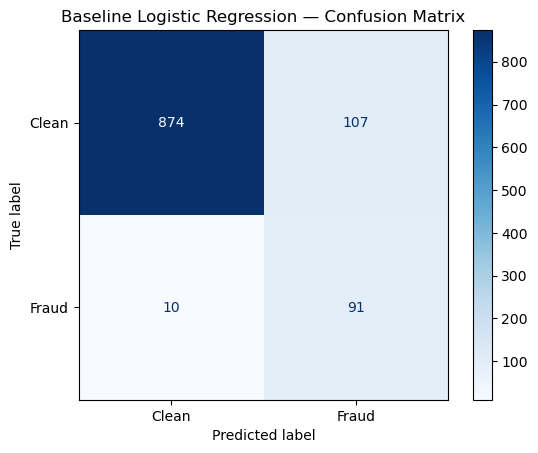


True Negatives  (correctly called clean):  874
False Positives (wrongly flagged as fraud): 107
False Negatives (missed fraudsters):        10
True Positives  (correctly caught fraud):   91

Fraudsters caught: 91/101 (90.1%)


In [40]:
# Cell — Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['Clean', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('Baseline Logistic Regression — Confusion Matrix')
plt.show()

# Print readable version
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correctly called clean):  {tn}")
print(f"False Positives (wrongly flagged as fraud): {fp}")
print(f"False Negatives (missed fraudsters):        {fn}")
print(f"True Positives  (correctly caught fraud):   {tp}")
print(f"\nFraudsters caught: {tp}/{tp+fn} ({tp/(tp+fn)*100:.1f}%)")

In [41]:
# Cell — Calculate scale_pos_weight
negative_cases = (y_train == 0).sum()  # clean providers
positive_cases = (y_train == 1).sum()  # fraud providers

scale = negative_cases / positive_cases
print(f"Clean providers in train: {negative_cases}")
print(f"Fraud providers in train: {positive_cases}")
print(f"scale_pos_weight: {scale:.2f}")

Clean providers in train: 3923
Fraud providers in train: 405
scale_pos_weight: 9.69


In [49]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
  Using cached xgboost-3.3.0-py3-none-win_amd64.whl.metadata (2.0 kB)
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.8/69.5 MB 1.6 MB/s eta 0:00:42
    --------------------------------------- 1.0/69.5 MB 1.5 MB/s eta 0:00:46
    --------------------------------------- 1.3/69.5 MB 1.6 MB/s eta 0:00:42
   - -------------------------------------- 1.8/69.5 MB 1.7 MB/s eta 0:00:40
   - -------------------------------------- 2.4/69.5 MB 1.8 MB/s eta 0:00:37
   - -------------------------------------- 2.9/69.5 MB 2.0 MB/s eta 0:00:35
   - -------------------------------------- 3.4/69.5 MB 2.0 MB/s eta 0:00:33
   -- ------------------------------------- 4.2/69.5 MB 2.1 MB/s eta 0:00:31
   -- --------------------

In [50]:
from xgboost import XGBClassifier
print("XGBoost imported")
# Cell — Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    eval_metric='auc',
    random_state=42,
    use_label_encoder=False
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("\nTraining complete")

XGBoost imported
[0]	validation_0-auc:0.91011
[50]	validation_0-auc:0.96777
[100]	validation_0-auc:0.96814


C:\Users\SATYAM KUMAR SINGH\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [16:30:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[150]	validation_0-auc:0.96871
[200]	validation_0-auc:0.96848
[250]	validation_0-auc:0.96783
[299]	validation_0-auc:0.96746

Training complete


In [51]:
# Cell — Evaluate XGBoost
y_pred_xgb       = xgb_model.predict(X_test)
y_pred_xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

auc_xgb = roc_auc_score(y_test, y_pred_xgb_proba)
print(f"XGBoost AUC-ROC: {auc_xgb:.4f}")
print(f"Baseline AUC-ROC: 0.9669")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb,
                            target_names=['Clean', 'Fraud']))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_xgb).ravel()
print(f"True Negatives  (correctly called clean):  {tn}")
print(f"False Positives (wrongly flagged as fraud): {fp}")
print(f"False Negatives (missed fraudsters):        {fn}")
print(f"True Positives  (correctly caught fraud):   {tp}")
print(f"\nFraudsters caught: {tp}/{tp+fn} ({tp/(tp+fn)*100:.1f}%)")

XGBoost AUC-ROC: 0.9675
Baseline AUC-ROC: 0.9669

Classification Report:
              precision    recall  f1-score   support

       Clean       0.97      0.95      0.96       981
       Fraud       0.62      0.73      0.67       101

    accuracy                           0.93      1082
   macro avg       0.79      0.84      0.82      1082
weighted avg       0.94      0.93      0.94      1082

True Negatives  (correctly called clean):  935
False Positives (wrongly flagged as fraud): 46
False Negatives (missed fraudsters):        27
True Positives  (correctly caught fraud):   74

Fraudsters caught: 74/101 (73.3%)


In [54]:
from sklearn.metrics import recall_score, precision_score, f1_score

print("=" * 52)
print(f"{'Metric':<25} {'Baseline':>12} {'XGBoost':>12}")
print("-" * 52)
print(f"{'AUC-ROC':<25} {0.9669:>12.4f} {auc_xgb:>12.4f}")
print(f"{'Recall':<25} {0.9010:>12.4f} {recall_score(y_test, y_pred_xgb):>12.4f}")
print(f"{'Precision':<25} {0.4600:>12.4f} {precision_score(y_test, y_pred_xgb):>12.4f}")
print(f"{'F1 Score':<25} {0.6100:>12.4f} {f1_score(y_test, y_pred_xgb):>12.4f}")
print("=" * 52)

Metric                        Baseline      XGBoost
----------------------------------------------------
AUC-ROC                         0.9669       0.9675
Recall                          0.9010       0.7327
Precision                       0.4600       0.6167
F1 Score                        0.6100       0.6697


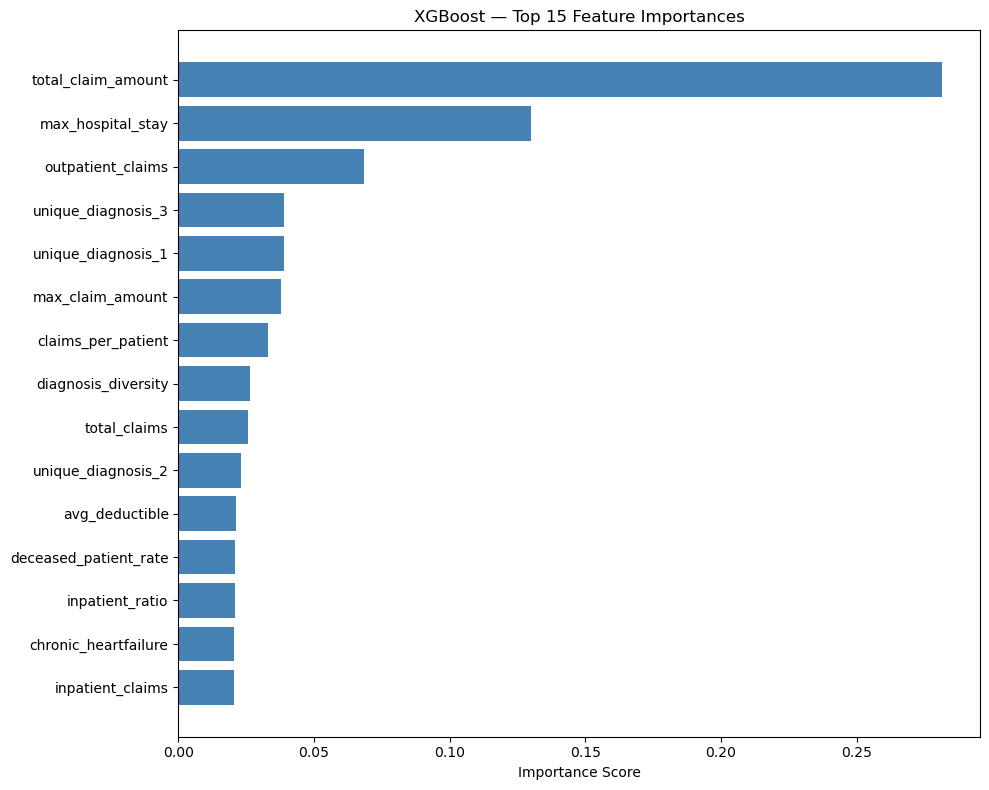


Top 10 features:
            feature  importance
 total_claim_amount    0.281345
  max_hospital_stay    0.129914
  outpatient_claims    0.068457
 unique_diagnosis_3    0.038881
 unique_diagnosis_1    0.038846
   max_claim_amount    0.037891
 claims_per_patient    0.033013
diagnosis_diversity    0.026456
       total_claims    0.025844
 unique_diagnosis_2    0.023212


In [53]:
# Cell — Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'][:15],
         feature_importance['importance'][:15],
         color='steelblue')
plt.xlabel('Importance Score')
plt.title('XGBoost — Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(feature_importance.head(10).to_string(index=False))

In [56]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


In [57]:
import shap
print(f"SHAP version: {shap.__version__}")

SHAP version: 0.52.0


In [58]:
# Cell — Create explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for test set
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
# Should be (1082, 26) — one row per test provider, one col per feature
print("SHAP values calculated successfully")

SHAP values shape: (1082, 26)
SHAP values calculated successfully


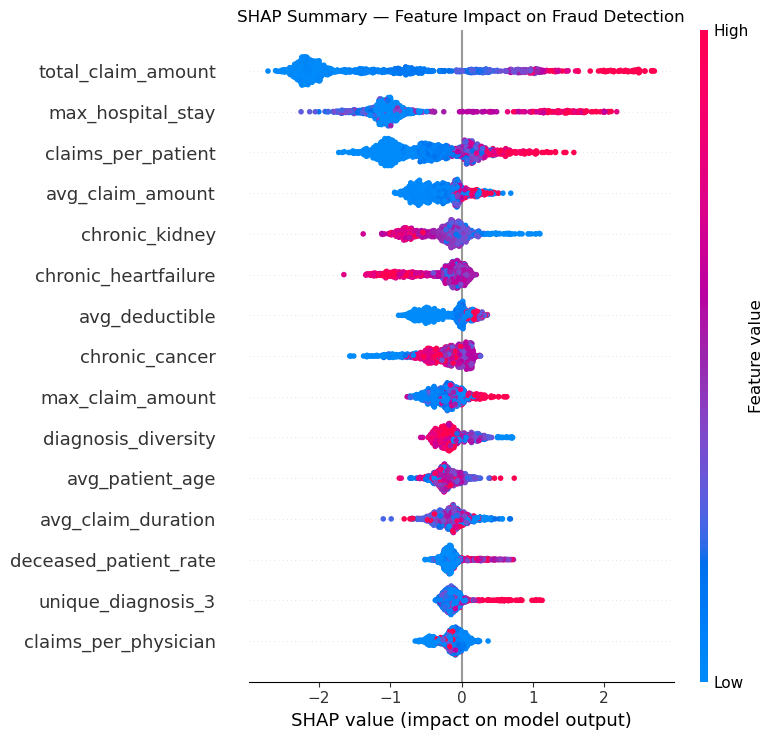

Summary plot saved


In [59]:
# Cell — Summary plot
plt.figure()
shap.summary_plot(
    shap_values, 
    X_test,
    plot_type="dot",
    max_display=15,
    show=False
)
plt.title("SHAP Summary — Feature Impact on Fraud Detection")
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary plot saved")

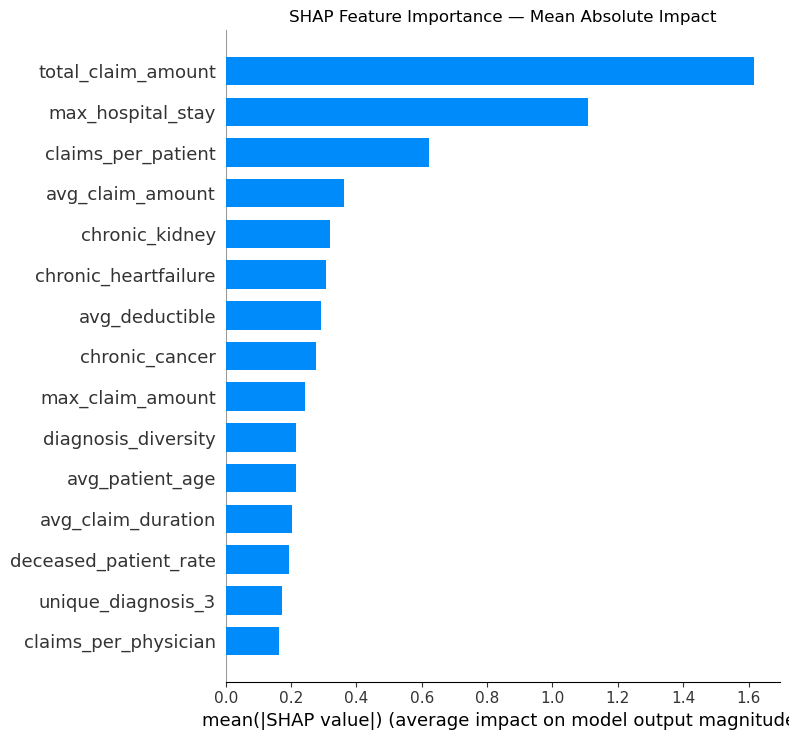

In [60]:
# Cell — Bar summary plot
plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("SHAP Feature Importance — Mean Absolute Impact")
plt.tight_layout()
plt.savefig('shap_bar_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [61]:
# Cell — Find highest risk providers in test set
# Get fraud probabilities for test set
test_proba = xgb_model.predict_proba(X_test)[:, 1]

# Add to a dataframe for easy viewing
test_results = X_test.copy()
test_results['fraud_probability'] = test_proba
test_results['actual_fraud']      = y_test.values

# Sort by fraud probability descending
test_results = test_results.sort_values('fraud_probability', ascending=False)

print("Top 10 highest risk providers:")
print(test_results[['fraud_probability', 'actual_fraud', 
                     'total_claim_amount', 'max_hospital_stay',
                     'inpatient_ratio']].head(10).round(3))

Top 10 highest risk providers:
      fraud_probability  actual_fraud  total_claim_amount  max_hospital_stay  \
1596              0.999             1             1720120               35.0   
3018              0.999             1             1751320               35.0   
4446              0.999             1             3212000               35.0   
4334              0.999             1             2744870               35.0   
3000              0.998             1             2969530               35.0   
4922              0.998             1             1386100               35.0   
3363              0.998             1             2284560               34.0   
1071              0.998             1             2540130               35.0   
5232              0.997             1             1069050               35.0   
4513              0.997             1             1288910               35.0   

      inpatient_ratio  
1596            0.086  
3018            0.052  
4446            

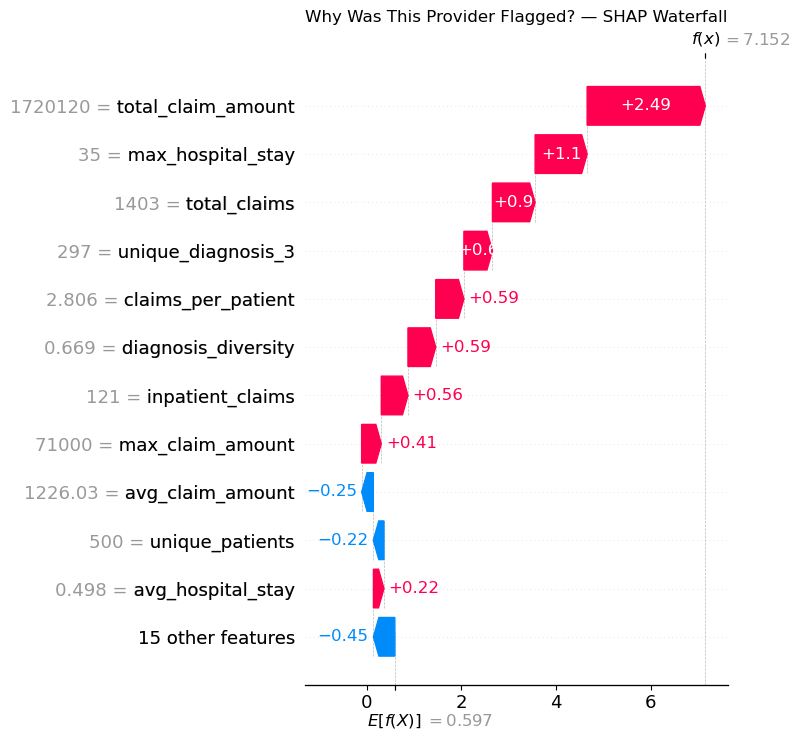


Highest risk provider details:
Fraud probability: 0.999
Actually fraud: 1
Total claim amount: $1,720,120
Max hospital stay: 35 days
Inpatient ratio: 0.086


In [62]:
# Cell — Waterfall plot for the highest risk provider
# Get index of highest risk provider
highest_risk_idx = test_results.index[0]
position_in_test = list(X_test.index).index(highest_risk_idx)

# Create SHAP explanation object
explanation = shap.Explanation(
    values     = shap_values[position_in_test],
    base_values= explainer.expected_value,
    data       = X_test.iloc[position_in_test],
    feature_names = X_test.columns.tolist()
)

# Plot waterfall
plt.figure()
shap.waterfall_plot(explanation, max_display=12, show=False)
plt.title("Why Was This Provider Flagged? — SHAP Waterfall")
plt.tight_layout()
plt.savefig('shap_waterfall_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the provider's details
print(f"\nHighest risk provider details:")
print(f"Fraud probability: {test_results['fraud_probability'].iloc[0]:.3f}")
print(f"Actually fraud: {test_results['actual_fraud'].iloc[0]}")
print(f"Total claim amount: ${test_results['total_claim_amount'].iloc[0]:,.0f}")
print(f"Max hospital stay: {test_results['max_hospital_stay'].iloc[0]:.0f} days")
print(f"Inpatient ratio: {test_results['inpatient_ratio'].iloc[0]:.3f}")

In [63]:
# Cell — Export SHAP values
shap_df = pd.DataFrame(
    shap_values,
    columns=[f'shap_{col}' for col in X_test.columns]
)

# Add provider details
shap_df['fraud_probability'] = test_proba
shap_df['actual_fraud']      = y_test.values
shap_df['predicted_fraud']   = xgb_model.predict(X_test)

# Add top contributing feature for each provider
shap_cols = [f'shap_{col}' for col in X_test.columns]
shap_df['top_fraud_driver'] = shap_df[shap_cols].abs().idxmax(axis=1)
shap_df['top_fraud_driver'] = shap_df['top_fraud_driver'].str.replace('shap_', '')

print(f"SHAP dataframe shape: {shap_df.shape}")
print("\nTop fraud drivers distribution:")
print(shap_df[shap_df['actual_fraud']==1]['top_fraud_driver'].value_counts())

# Export
shap_df.to_csv('shap_values_output.csv', index=False)
print("\nExported to shap_values_output.csv")

SHAP dataframe shape: (1082, 30)

Top fraud drivers distribution:
top_fraud_driver
total_claim_amount      58
max_hospital_stay       36
claims_per_patient       4
chronic_heartfailure     1
avg_patient_age          1
avg_hospital_stay        1
Name: count, dtype: int64

Exported to shap_values_output.csv


In [64]:
# Cell — Final provider risk output
# Get provider IDs for test set
test_provider_ids = provider_df.loc[X_test.index, 'Provider'].values

risk_output = pd.DataFrame({
    'Provider'         : test_provider_ids,
    'FraudProbability' : test_proba.round(4),
    'RiskCategory'     : pd.cut(test_proba,
                                bins=[0, 0.3, 0.6, 0.8, 1.0],
                                labels=['Low', 'Medium', 'High', 'Critical']),
    'ActualFraud'      : y_test.values,
    'PredictedFraud'   : xgb_model.predict(X_test),
    'TopFraudDriver'   : shap_df['top_fraud_driver'].values,
    'TotalClaimAmount' : X_test['total_claim_amount'].values,
    'MaxHospitalStay'  : X_test['max_hospital_stay'].values,
    'InpatientRatio'   : X_test['inpatient_ratio'].round(3).values
})

risk_output = risk_output.sort_values('FraudProbability', ascending=False)

print("Risk category distribution:")
print(risk_output['RiskCategory'].value_counts())

print("\nTop 15 highest risk providers:")
print(risk_output.head(15).to_string(index=False))

# Export for Power BI
risk_output.to_csv('provider_risk_scores.csv', index=False)
print("\nExported to provider_risk_scores.csv")

Risk category distribution:
RiskCategory
Low         928
Critical     83
Medium       46
High         25
Name: count, dtype: int64

Top 15 highest risk providers:
Provider  FraudProbability RiskCategory  ActualFraud  PredictedFraud     TopFraudDriver  TotalClaimAmount  MaxHospitalStay  InpatientRatio
PRV52985            0.9992     Critical            1               1 total_claim_amount           1720120             35.0           0.086
PRV56560            0.9990     Critical            1               1 total_claim_amount           3212000             35.0           0.107
PRV54772            0.9990     Critical            1               1 total_claim_amount           1751320             35.0           0.052
PRV56416            0.9986     Critical            1               1 total_claim_amount           2744870             35.0           0.134
PRV54742            0.9984     Critical            1               1 total_claim_amount           2969530             35.0           0.122
PRV

In [65]:
# Cell — Export provider features for Power BI
provider_export = provider_df.copy()
provider_export['FraudProbability'] = xgb_model.predict_proba(X)[:, 1].round(4)
provider_export['RiskCategory'] = pd.cut(
    provider_export['FraudProbability'],
    bins=[0, 0.3, 0.6, 0.8, 1.0],
    labels=['Low', 'Medium', 'High', 'Critical']
)
provider_export['PredictedFraud'] = xgb_model.predict(X)

provider_export.to_csv('provider_features_full.csv', index=False)
print(f"Exported: {provider_export.shape}")
print(provider_export['RiskCategory'].value_counts())

Exported: (5410, 31)
RiskCategory
Low         4721
Critical     489
Medium       156
High          44
Name: count, dtype: int64
